# Import & Setup

In [1]:
import os
if os.path.exists('digit_recognizer'):
    !rm -rf digit_recognizer
!git clone https://github.com/Sirius-Siru/digit_recognizer.git

import sys
if '/content/digit_recognizer' not in sys.path:
    sys.path.append('/content/digit_recognizer')

!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

if os.path.isdir('data') and os.path.exists('data/train.csv'):
    print("✨ Dữ liệu đã sẵn sàng, không cần tải lại.")
else:
    print("🚀 Đang tải dữ liệu...")
    !kaggle competitions download -c digit-recognizer
    !unzip -o digit-recognizer.zip -d data
    !rm -f digit-recognizer.zip

Cloning into 'digit_recognizer'...
remote: Enumerating objects: 229, done.
remote: Counting objects: 100% (229/229), done.
remote: Compressing objects: 100% (158/158), done.
remote: Total 229 (delta 120), reused 178 (delta 70), pack-reused 0 (from 0)
Receiving objects: 100% (229/229), 1.41 MiB | 19.58 MiB/s, done.
Resolving deltas: 100% (120/120), done.
✨ Dữ liệu đã sẵn sàng, không cần tải lại.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import src.preprocessing as pp

import gc
from joblib import Parallel, delayed

# Load data

In [3]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

X = train.drop('label', axis=1)
y = train['label']

# Unflatten & Normalize
train_img = X.values.reshape(-1, 28, 28) / 255.0
test_img = test.values.reshape(-1, 28, 28) / 255.0

# Preprocessing

In [4]:
from tensorflow.keras.utils import to_categorical

X = Parallel(n_jobs = -1)(delayed(pp.cnn_preprocess)(img) for img in train_img)
test = Parallel(n_jobs = -1)(delayed(pp.cnn_preprocess)(img) for img in test_img)

X = np.array(X)
test = np.array(test)

y = to_categorical(y, num_classes=10)

del train_img, test_img
gc.collect()

54

# Setup model

In [5]:
import tensorflow as tf

def to_3_channel(img):
    # img: (28, 28, 1), giá trị [0,1]
    img4d = tf.expand_dims(img, axis=0)

    # channel 1: original
    c1 = img

    # channel 2: edge (Sobel)
    edge = tf.image.sobel_edges(img4d)        # (28,28,1,2)
    edge = tf.reduce_mean(edge, axis=-1)    # (28,28,1)
    edge = tf.abs(edge)
    edge = tf.squeeze(edge, axis=0)

    # channel 3: dilation (làm đậm nét)
    kernel = tf.ones((3, 3, 1), dtype=tf.float64)
    c3 = tf.nn.dilation2d(
        input=img4d,
        filters=kernel,
        strides=[1,1,1,1],
        padding="SAME",
        data_format="NHWC",
        dilations=[1,1,1,1]
    )
    c3 = tf.squeeze(c3, axis=0)
    
    # ghép lại → (28,28,3)
    return tf.concat([c1, edge, c3], axis=-1)   

In [6]:
# Train-Test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 42)

# To 3 channels

In [7]:
import tensorflow as tf

# Chuyển NumPy array thành tf.data.Dataset
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_ds = tf.data.Dataset.from_tensor_slices(test)

# Bây giờ bạn có thể dùng .map() thoải mái
train_ds = train_ds.map(lambda x, y: (to_3_channel(x), y), 
                        num_parallel_calls=tf.data.AUTOTUNE)

val_ds = val_ds.map(lambda x, y: (to_3_channel(x), y), 
                      num_parallel_calls=tf.data.AUTOTUNE)

test_ds = test_ds.map(lambda x: (to_3_channel(x)), 
                      num_parallel_calls=tf.data.AUTOTUNE)

# Sau đó mới thực hiện batch và prefetch để tối ưu tốc độ
train_ds = train_ds.shuffle(10000).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Activation

def random_morphology(image):
    # Tạo số ngẫu nhiên để chọn 1 trong 3 trạng thái
    prob = tf.random.uniform([], 0, 1)
    
    # 1. Làm mỏng nét (Erosion) - dùng Min Pooling logic
    def erode():
        return -tf.nn.max_pool2d(-image, ksize=3, strides=1, padding='SAME')
    
    # 2. Làm dày nét (Dilation) - dùng Max Pooling
    def dilate():
        return tf.nn.max_pool2d(image, ksize=3, strides=1, padding='SAME')
    
    # Sử dụng tf.case để chọn nhánh xử lý
    return tf.case([
        (prob < 0.33, erode),
        (prob < 0.66, dilate)
    ], default=lambda: image)

data_augmentation = models.Sequential([
  layers.RandomRotation(0.20, input_shape=(28, 28, 3)),
  layers.RandomZoom(0.05),
  layers.RandomTranslation(0.05, 0.05),
  layers.Lambda(lambda x: random_morphology(x)),
  layers.RandomGaussianBlur(0.01),
  layers.GaussianNoise(0.1)
])

model = models.Sequential([
    layers.Input(shape=(28, 28, 3)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), use_bias=False),
    layers.BatchNormalization(),
    Activation('relu'),
    layers.Conv2D(32, (3, 3), use_bias=False),
    layers.BatchNormalization(),
    Activation('relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), use_bias=False),
    layers.BatchNormalization(),
    Activation('relu'),
    layers.Conv2D(64, (3, 3), use_bias=False),
    layers.BatchNormalization(),
    Activation('relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128),
    layers.BatchNormalization(),
    Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(optimizer='adam',
              loss=loss,
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
import keras

mixup_layer = keras.layers.MixUp(alpha=0.1) 

In [10]:
def apply_mixup(images, labels):
    # Đóng gói thành dict cho MixUp layer hiểu
    inputs = {"images": images, "labels": labels}
    
    # Chạy qua layer MixUp
    outputs = mixup_layer(inputs)
    
    # BÓC TÁCH DICT THÀNH TUPLE ĐỂ MODEL KHÔNG BỊ "MẤT LABEL"
    return outputs["images"], outputs["labels"]

# BƯỚC C: Gọi hàm apply_mixup
train_ds = train_ds.map(apply_mixup, num_parallel_calls=tf.data.AUTOTUNE)

# BƯỚC D: Tối ưu prefetch
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

# Train model

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)
model.fit(train_ds, epochs=50, validation_data=val_ds, callbacks = [early_stop, reduce_lr])

Epoch 1/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 167s 146ms/step - accuracy: 0.7658 - loss: 1.2135 - val_accuracy: 0.8192 - val_loss: 0.9940 - learning_rate: 0.0010
Epoch 2/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 150s 139ms/step - accuracy: 0.8931 - loss: 0.9569 - val_accuracy: 0.7887 - val_loss: 1.0603 - learning_rate: 0.0010
Epoch 3/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 150s 139ms/step - accuracy: 0.9151 - loss: 0.9112 - val_accuracy: 0.9117 - val_loss: 0.7862 - learning_rate: 0.0010
Epoch 4/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 203s 141ms/step - accuracy: 0.9248 - loss: 0.8848 - val_accuracy: 0.8912 - val_loss: 0.8229 - learning_rate: 0.0010
Epoch 5/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 147s 138ms/step - accuracy: 0.9287 - loss: 0.8728 - val_accuracy: 0.9455 - val_loss: 0.7003 - learning_rate: 0.0010
Epoch 6/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 154s 144ms/step - accuracy: 0.9344 - loss: 0.8613 - val_accuracy: 0.9517 - val_loss: 0.6989 - learning_rate: 0.0010
Epoch 7/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 143s 133ms

263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step
Accuracy = 96.94


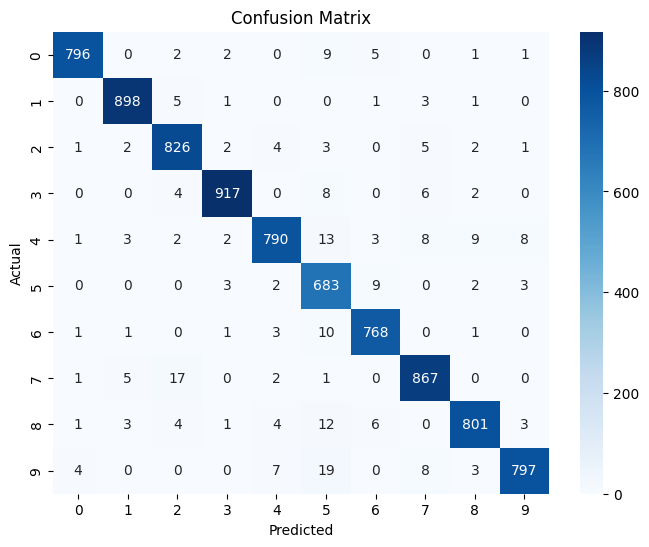

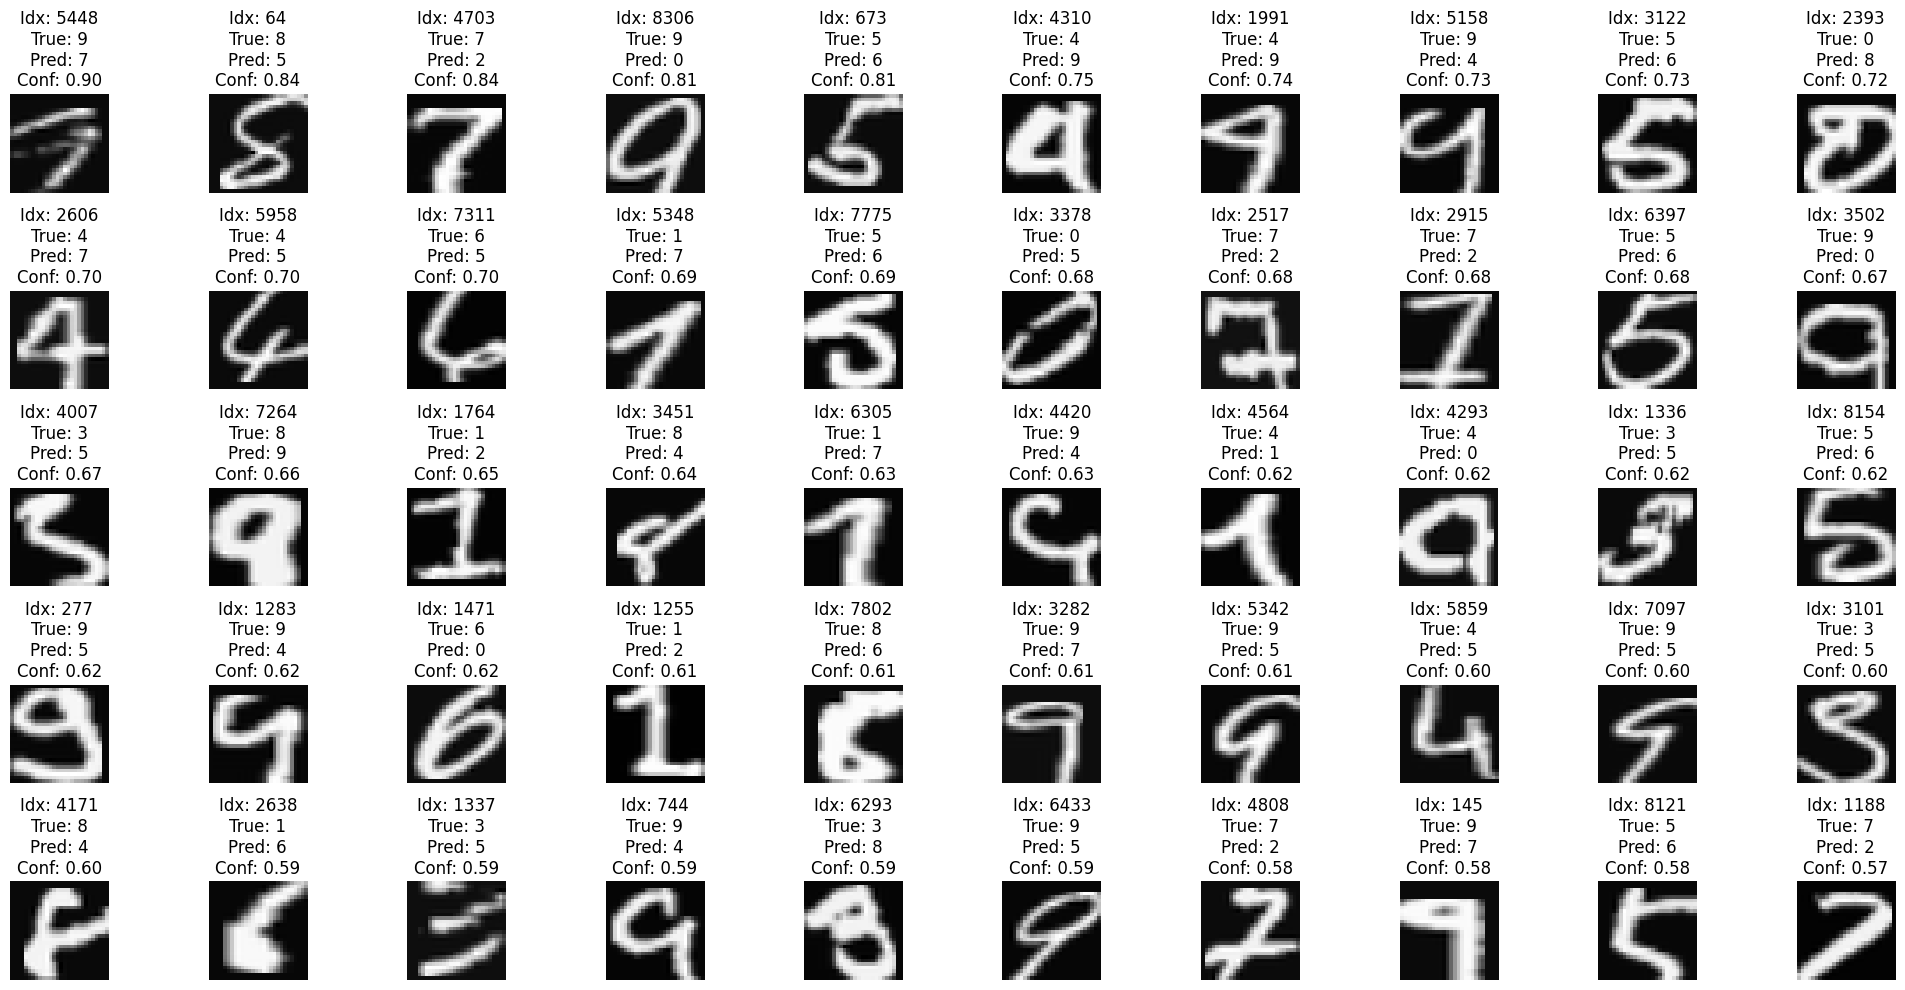

In [12]:
import numpy as np
import pandas as pd
import src.evaluate as eva

# 1. Trích xuất X_val và y_val từ tf.data.Dataset
x_val_list = []
y_val_list = []

for images, labels in val_ds:
    x_val_list.append(images.numpy())
    y_val_list.append(labels.numpy())

X_val = np.concatenate(x_val_list, axis=0) # Shape lúc này là (N, 28, 28, 3)
y_val = np.concatenate(y_val_list, axis=0)

# 2. Predict
probs = model.predict(val_ds)
y_pred = np.argmax(probs, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

# 3. Chạy hàm đánh giá
eva.evaluate(y_true_classes, y_pred)

# 4. SỬA LỖI Ở ĐÂY: Chỉ lấy kênh ảnh gốc (Channel 0) để hiển thị
# X_val_original sẽ có shape (N, 28, 28), tương đương với 784 pixels mỗi ảnh
X_val_original = X_val[:, :, :, 0]

y_true_series = pd.DataFrame(y_true_classes).squeeze()

# Truyền X_val_original vào thay vì X_val 3 kênh
eva.showWrongCase(model, X_val_original, y_true_series, probs)

# Submission

In [13]:
# model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
#               loss=loss,
#               metrics=['accuracy'])

# model.fit(X, y, epochs=5)
# submission = model.predict(test)

In [14]:
# labels = np.argmax(submission, axis = 1)
# submission = pd.DataFrame(data = labels, columns=['Label'])
# submission.insert(0, 'ImageId', range(1, len(submission)+1))
# submission.to_csv('submission.csv', index = False)

In [15]:
# !kaggle competitions submit -c digit-recognizer -f submission.csv  -m "First submit of the day"